# 💼 Salary Survey — Data Cleaning Notebook
**Môn:** Data Handling & Visualization · Handout Bài 02  
**Dataset:** `salary_survey_raw.csv` — 2.800 hàng × 17 cột  
**Mục tiêu:** Xử lý & làm sạch dữ liệu, viết pipeline tái sử dụng được, xuất Data Quality Report.

---


In [2]:
# Cài thư viện cần thiết 
import subprocess, sys
pkgs = ['rapidfuzz', 'category_encoders']
for pkg in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('Cài đặt thành công!')

Cài đặt thành công!


## 0. Setup — Import thư viện & load dữ liệu

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from rapidfuzz import fuzz, process
import category_encoders as ce

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 60)

# Load raw data
df_raw = pd.read_csv('salary_survey_raw.csv')
print(f'Raw shape: {df_raw.shape}')
df_raw.head(3)


Raw shape: (2800, 17)


,timestamp,how_old_are_you,industry,job_title,additional_context_on_job_title,annual_salary,additional_monetary_comp,currency,income_context,country,us_state,city,years_of_experience_in_field,years_of_experience_overall,highest_level_of_education,gender,race
0,04/12/2021 16:11:47,45-54,Legal,Legal Counsel,NaN,"56,894",NaN,USD,NaN,NaN,NaN,Boston,21 - 30 years,21 - 30 years,College degree,Man,Black or African American
1,04/25/2021 09:28:06,25-34,Finance,Investment Analyst,NaN,"144,543","$9,839",USD,NaN,United States,Washington,NaN,8 - 10 years,8 - 10 years,College degree,Man,Multiracial
2,04/15/2021,25-34,Nonprofit,Grant Writer,NaN,"52,304.00",NaN,AUD,NaN,United States,Washington,NaN,21 - 30 years,21 - 30 years,PhD,Woman,NaN


## 1. Tổng quan Dataset gốc

Trước khi xử lý bất cứ điều gì, cần nắm rõ "bức tranh toàn cảnh" của dữ liệu:  
shape, dtypes, tỉ lệ null, duplicate.  
Đây là bước bắt buộc — xử lý mù sẽ dẫn đến quyết định sai.


In [4]:
# ── Tổng quan cơ bản ──
print("=" * 55)
print(f"Shape         : {df_raw.shape[0]:,} hàng × {df_raw.shape[1]} cột")
print(f"Duplicate     : {df_raw.duplicated().sum():,} hàng")
print(f"Tổng ô null   : {df_raw.isnull().sum().sum():,}")
print("=" * 55)
print()
print("Dtypes:")
print(df_raw.dtypes)


Shape         : 2,800 hàng × 17 cột
Duplicate     : 38 hàng
Tổng ô null   : 9,492

Dtypes:
timestamp                          str
how_old_are_you                    str
industry                           str
job_title                          str
additional_context_on_job_title    str
annual_salary                      str
additional_monetary_comp           str
currency                           str
income_context                     str
country                            str
us_state                           str
city                               str
years_of_experience_in_field       str
years_of_experience_overall        str
highest_level_of_education         str
gender                             str
race                               str
dtype: object


In [5]:
# ── Hàm báo cáo missing values ──
def missing_report(df):
    miss  = df.isnull().sum()
    pct   = (miss / len(df) * 100).round(2)
    report = (pd.DataFrame({'null_count': miss, 'null_pct': pct})
              .query('null_count > 0')
              .sort_values('null_pct', ascending=False))
    return report

print("Missing values per column:")
missing_report(df_raw)


Missing values per column:


,null_count,null_pct
income_context,2269,81.04
us_state,1813,64.75
city,1562,55.79
additional_monetary_comp,1538,54.93
additional_context_on_job_title,969,34.61
race,766,27.36
annual_salary,391,13.96
country,115,4.11
gender,69,2.46


---
## TUẦN 1 — Missing Values, Duplicates & Data Types


### 1.1 Missing Values

**Nguyên tắc quan trọng:** không phải `null` nào cũng xử lý giống nhau.  
Trước mỗi quyết định phải đặt câu hỏi: *null này xuất hiện vì lý do gì?*

Có ba loại null chính:
- **MCAR** (Missing Completely At Random): null xuất hiện ngẫu nhiên, không liên quan gì đến giá trị thực.
- **MAR** (Missing At Random): null phụ thuộc vào các cột khác (ví dụ: `us_state` null vì người đó không ở Mỹ).
- **MNAR** (Missing Not At Random): null có *ý nghĩa* — người không điền vì bản thân giá trị đó nhạy cảm (ví dụ: lương thấp thì ngại khai).

Xử lý MNAR bằng `fillna` đơn giản sẽ gây ra **bias có hệ thống** trong phân tích.


In [6]:
# Xem chi tiết missing theo từng cột
mr = missing_report(df_raw).copy()
mr


,null_count,null_pct
income_context,2269,81.04
us_state,1813,64.75
city,1562,55.79
additional_monetary_comp,1538,54.93
additional_context_on_job_title,969,34.61
race,766,27.36
annual_salary,391,13.96
country,115,4.11
gender,69,2.46


**Phân tích từng cột null:**

| Cột | % null | Loại null | Quyết định | Lý do |
|---|---|---|---|---|
| `income_context` | 81% | MCAR — free text tùy chọn | `fillna('none')` | Null hợp lệ, không ảnh hưởng phân tích chính |
| `us_state` | 65% | MAR — phụ thuộc country | `fillna('N/A')` | Người ngoài nước Mỹ không có state, null có ý nghĩa |
| `city` | 56% | MAR | `fillna('Unknown')` | Tương tự us_state — không bắt buộc điền |
| `additional_monetary_comp` | 55% | MCAR | `fillna(0)` | Không có bonus thì = 0 là hợp lý về nghiệp vụ |
| `race` | 27% | MNAR — thông tin nhạy cảm | `fillna('Prefer not to say')` | Không drop vì mất ~750 hàng, gắn label rõ ràng |
| `annual_salary` | 14% | MNAR — người thu nhập thấp ngại khai | fillna median theo industry + flag | Giải thích chi tiết trong Decision Log bên dưới |
| `country` | 4% | MCAR | `fillna('Unknown')` | Tỉ lệ thấp, ảnh hưởng nhỏ |
| `gender` | 2.5% | MNAR nhẹ | `fillna('Prefer not to say')` | Tôn trọng quyền riêng tư |

**Quyết định khó nhất — `annual_salary` (14% null):**  
Đây là cột quan trọng nhất của dataset. Hai phương án:  
- **Phương án 1 — Drop hàng null:** Đơn giản, dữ liệu sạch. Nhược: mất 391 hàng, có thể gây bias nếu MNAR (ngành lương thấp bị loại nhiều hơn).  
- **Phương án 2 — fillna(median theo industry) + cột flag:** Giữ được data, ước tính có điều kiện theo ngành hợp lý hơn fillna global. Nhược: nếu MNAR thực sự → vẫn bị bias nhẹ.  

**Chọn Phương án 2** vì phân tích chính là so sánh lương theo ngành — mất 14% data có thể làm lệch kết quả ở ngành có lương thấp.  
Thêm cột `salary_was_imputed = True/False` để người đọc sau biết hàng nào đã được điền.


In [7]:
df = df_raw.copy()

# ── Lưu null count trước xử lý để so sánh sau ──
null_before = df.isnull().sum()

# ── Các cột free-text / tùy chọn: null = hợp lệ ──
# LÝ DO: income_context là ghi chú tự do, null không ảnh hưởng phân tích
df['income_context'] = df['income_context'].fillna('none')

# LÝ DO: us_state null = người không ở Mỹ, đây là null có ý nghĩa địa lý
df['us_state'] = df['us_state'].fillna('N/A')

# LÝ DO: city không bắt buộc, fillna('Unknown') thay vì drop vì cột này không phải key field
df['city'] = df['city'].fillna('Unknown')

# LÝ DO: additional_monetary_comp null = không có khoản bổ sung → điền 0 hợp lý về nghiệp vụ
df['additional_monetary_comp'] = df['additional_monetary_comp'].fillna('0')

# LÝ DO: additional_context free text tùy chọn
df['additional_context_on_job_title'] = df['additional_context_on_job_title'].fillna('none')

# LÝ DO: race, gender — thông tin nhạy cảm, gắn nhãn rõ ràng thay vì drop
df['race']   = df['race'].fillna('Prefer not to say')
df['gender'] = df['gender'].fillna('Prefer not to say')

# LÝ DO: country 4% null — điền Unknown, ảnh hưởng nhỏ
df['country'] = df['country'].fillna('Unknown')

# ── annual_salary: Phương án 2 — fillna median theo industry + flag ──
# Bước 1: Convert sang số trước (xử lý dtype ở bước 1.3, làm sớm ở đây vì cần để fillna)
df['annual_salary'] = (df['annual_salary']
    .astype(str)
    .str.strip()
    .str.replace(',', '', regex=False)
    .str.replace('$', '', regex=False)
    .str.replace(' ', '', regex=False))
df['annual_salary'] = pd.to_numeric(df['annual_salary'], errors='coerce')

# Bước 2: Tạo flag trước khi fillna
df['salary_was_imputed'] = df['annual_salary'].isnull()

# Bước 3: fillna median theo industry
industry_median = df.groupby('industry')['annual_salary'].median()
df['annual_salary'] = df.groupby('industry')['annual_salary'].transform(
    lambda x: x.fillna(x.median())
)
# Fallback: một số industry có thể vẫn còn null nếu toàn ngành đó null
df['annual_salary'] = df['annual_salary'].fillna(df['annual_salary'].median())

print(f"Hàng salary được imputed: {df['salary_was_imputed'].sum()}")
print()
print("Null còn lại sau xử lý missing:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Hàng salary được imputed: 395

Null còn lại sau xử lý missing:
Series([], dtype: int64)


### 1.2 Duplicates

Sau khi phát hiện duplicate, phải hỏi: **tại sao xuất hiện?**  
- Nếu toàn hàng giống nhau → khả năng cao là lỗi nhập liệu / submit form nhiều lần.  
- Nếu chỉ trùng một số cột key → có thể là người dùng cập nhật thông tin (duplicate có ý nghĩa).

Ở dataset này, survey Google Form — người dùng có thể submit nhiều lần → **duplicate toàn hàng = lỗi nhập liệu** → giữ lần đầu tiên (`keep='first'`).


In [8]:
# ── Kiểm tra duplicate ──
n_dup_full = df.duplicated().sum()
print(f"Duplicate toàn hàng: {n_dup_full} ({n_dup_full/len(df)*100:.1f}%)")

# Kiểm tra theo key columns (timestamp + job_title như một proxy unique)
key_dup = df.duplicated(subset=['timestamp', 'job_title', 'annual_salary']).sum()
print(f"Duplicate theo key columns (timestamp+job+salary): {key_dup}")

shape_before = df.shape
df = df.drop_duplicates(keep='first').reset_index(drop=True)
shape_after = df.shape

print(f"\nShape trước: {shape_before[0]:,} hàng")
print(f"Shape sau  : {shape_after[0]:,} hàng")
print(f"Đã xóa     : {shape_before[0] - shape_after[0]} hàng duplicate")


Duplicate toàn hàng: 38 (1.4%)
Duplicate theo key columns (timestamp+job+salary): 41

Shape trước: 2,800 hàng
Shape sau  : 2,762 hàng
Đã xóa     : 38 hàng duplicate


### 1.3 Data Types

**Tại sao dtype sai gây lỗi phân tích?**  
Nếu cột `annual_salary` lưu dạng `object` (string), lệnh `df['annual_salary'].mean()` sẽ báo lỗi hoặc cho kết quả vô nghĩa.  
`pd.to_datetime` với format không đồng nhất sẽ trả về `NaT` thay vì lỗi nếu dùng `errors='coerce'`.  
Cột category dạng `object` tốn bộ nhớ gấp 3–5 lần so với dtype `category`.


In [9]:
print("Dtypes hiện tại:")
print(df.dtypes)
print()

# ── annual_salary đã được convert ở bước 1.1 ──
# Kiểm tra lại
print("annual_salary dtype:", df['annual_salary'].dtype)
print("annual_salary sample:", df['annual_salary'].head(5).tolist())


Dtypes hiện tại:
timestamp                              str
how_old_are_you                        str
industry                               str
job_title                              str
additional_context_on_job_title        str
annual_salary                      float64
additional_monetary_comp               str
currency                               str
income_context                         str
country                                str
us_state                               str
city                                   str
years_of_experience_in_field           str
years_of_experience_overall            str
highest_level_of_education             str
gender                                 str
race                                   str
salary_was_imputed                    bool
dtype: object

annual_salary dtype: float64
annual_salary sample: [56894.0, 144543.0, 52304.0, 51765.0, 133218.0]


In [10]:
# ── Convert timestamp ──
# LÝ DO: timestamp lưu dạng string với nhiều format khác nhau (MM/DD/YYYY, YYYY-MM-DD, v.v.)
# errors='coerce' → format không nhận dạng được sẽ thành NaT thay vì raise exception
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Kiểm tra có NaT không
nat_count = df['timestamp'].isnull().sum()
print(f"NaT sau convert timestamp: {nat_count}")
print("Dtype timestamp:", df['timestamp'].dtype)
print()

# ── Convert additional_monetary_comp sang số ──
# LÝ DO: cần numeric để tính tổng comp sau này
df['additional_monetary_comp'] = (df['additional_monetary_comp']
    .astype(str)
    .str.strip()
    .str.replace(',', '', regex=False)
    .str.replace('$', '', regex=False))
df['additional_monetary_comp'] = pd.to_numeric(df['additional_monetary_comp'], errors='coerce').fillna(0)

# ── Convert categorical columns sang dtype 'category' ──
# LÝ DO: tiết kiệm bộ nhớ, tăng tốc group-by operations
cat_cols = ['industry', 'currency', 'how_old_are_you',
            'years_of_experience_in_field', 'years_of_experience_overall',
            'highest_level_of_education']

mem_before = df[cat_cols].memory_usage(deep=True).sum() / 1024
for col in cat_cols:
    df[col] = df[col].astype('category')
mem_after = df[cat_cols].memory_usage(deep=True).sum() / 1024

print(f"Bộ nhớ categorical cols trước: {mem_before:.1f} KB")
print(f"Bộ nhớ categorical cols sau  : {mem_after:.1f} KB")
print(f"Tiết kiệm: {(1 - mem_after/mem_before)*100:.1f}%")
print()
print("Dtypes sau khi convert:")
print(df.dtypes)


NaT sau convert timestamp: 1343
Dtype timestamp: datetime64[us]

Bộ nhớ categorical cols trước: 1081.4 KB
Bộ nhớ categorical cols sau  : 20.2 KB
Tiết kiệm: 98.1%

Dtypes sau khi convert:
timestamp                          datetime64[us]
how_old_are_you                          category
industry                                 category
job_title                                     str
additional_context_on_job_title               str
annual_salary                             float64
additional_monetary_comp                  float64
currency                                 category
income_context                                str
country                                       str
us_state                                      str
city                                          str
years_of_experience_in_field             category
years_of_experience_overall              category
highest_level_of_education               category
gender                                        str
race         

In [11]:
# ── Bảng so sánh null trước / sau Tuần 1 ──
null_after_w1 = df.isnull().sum()
comparison_w1 = pd.DataFrame({
    'null_TRƯỚC': null_before,
    'null_SAU'  : null_after_w1,
    'giảm'      : null_before - null_after_w1,
})
print("So sánh null trước/sau Tuần 1:")
comparison_w1[comparison_w1['null_TRƯỚC'] > 0]


So sánh null trước/sau Tuần 1:


,null_TRƯỚC,null_SAU,giảm
additional_context_on_job_title,969.0,0,969.0
additional_monetary_comp,1538.0,0,1538.0
annual_salary,391.0,0,391.0
city,1562.0,0,1562.0
country,115.0,0,115.0
gender,69.0,0,69.0
income_context,2269.0,0,2269.0
race,766.0,0,766.0
us_state,1813.0,0,1813.0


---
## TUẦN 2 — Outliers, Chuẩn hóa Chuỗi & Normalization


### 2.1 Outliers

**Quan điểm quan trọng:** outlier không phải luôn là lỗi.  
- Một CEO lương 1.2 triệu USD là outlier về số học, nhưng là dữ liệu *hoàn toàn hợp lệ*.  
- Ngược lại, lương = 5,000 USD/năm ở Mỹ gần như chắc chắn là lỗi nhập liệu hoặc người dùng điền lương tháng thay vì lương năm.

Trước khi xử lý: **phát hiện → phân loại → quyết định**.


In [13]:
# ── Hàm phát hiện outlier IQR ──
# LÝ DO chọn IQR: salary phân phối lệch phải (right-skewed) — IQR robust hơn Z-score với skewed data
def detect_outliers_iqr(df, col):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"[IQR] {col}: lower={lower:,.0f}, upper={upper:,.0f}")
    print(f"  → {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")
    return outliers, lower, upper

# ── Hàm phát hiện outlier Z-score ──
def detect_outliers_zscore(df, col, thresh=3):
    z = (df[col] - df[col].mean()) / df[col].std()
    outliers = df[z.abs() > thresh]
    print(f"[Z-score|thresh={thresh}] {col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")
    return outliers

print("=== annual_salary ===")
sal_outliers_iqr, sal_lower, sal_upper = detect_outliers_iqr(df, 'annual_salary')
sal_outliers_z = detect_outliers_zscore(df, 'annual_salary')

print()
print("=== additional_monetary_comp ===")
comp_outliers_iqr, _, _ = detect_outliers_iqr(df, 'additional_monetary_comp')
comp_outliers_z = detect_outliers_zscore(df, 'additional_monetary_comp')


=== annual_salary ===
[IQR] annual_salary: lower=-17,695, upper=179,943
  → 126 outliers (4.6%)
[Z-score|thresh=3] annual_salary: 17 outliers (0.6%)

=== additional_monetary_comp ===
[IQR] additional_monetary_comp: lower=-4,674, upper=7,789
  → 365 outliers (13.2%)
[Z-score|thresh=3] additional_monetary_comp: 68 outliers (2.5%)


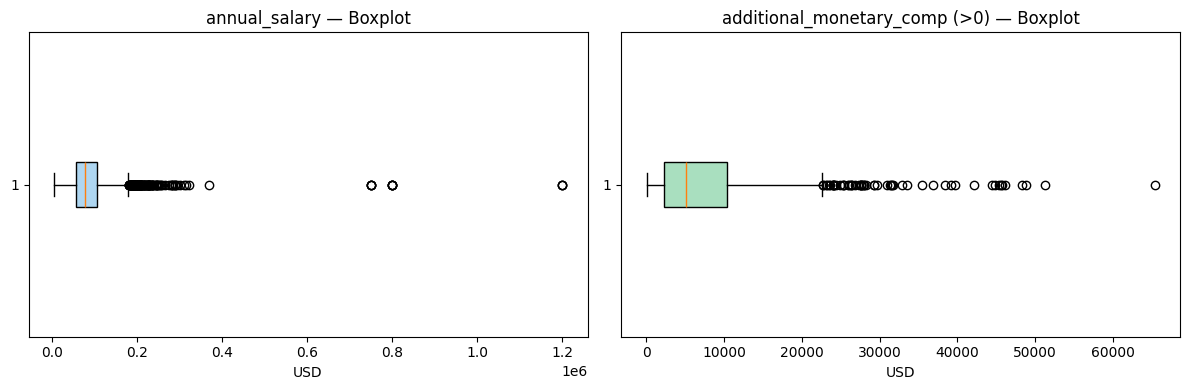

Boxplot đã lưu.


In [14]:
# ── Boxplot minh họa outlier ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df['annual_salary'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='#AED6F1'))
axes[0].set_title('annual_salary — Boxplot')
axes[0].set_xlabel('USD')

axes[1].boxplot(df[df['additional_monetary_comp'] > 0]['additional_monetary_comp'],
                vert=False, patch_artist=True,
                boxprops=dict(facecolor='#A9DFBF'))
axes[1].set_title('additional_monetary_comp (>0) — Boxplot')
axes[1].set_xlabel('USD')

plt.tight_layout()
plt.savefig('boxplot_outliers.png', dpi=100)
plt.show()
print("Boxplot đã lưu.")


**Phân tích outlier `annual_salary`:**

Phương pháp IQR và Z-score cho kết quả khác nhau vì Z-score nhạy hơn với phân phối chuẩn, còn IQR robust hơn với dữ liệu lệch.

Với lương:
- **Giá trị thấp (< ~15,000 USD):** Nhiều khả năng là người dùng nhập lương tháng hoặc lương theo giờ quy ra năm bị sai → **lỗi nhập liệu**.
- **Giá trị cao (> ~500,000 USD):** CEO, partner, executive level — **hợp lệ nhưng hiếm**. Không nên xóa vì sẽ làm sai phân tích phân khúc lương cao.

**Quyết định:** Áp dụng **Winsorize (clip tại 1st–99th percentile)** — giữ nguyên phân phối, chỉ "cắt đuôi" cực đoan. Không drop vì mất thông tin ngành.


In [15]:
# ── So sánh IQR vs Z-score ──
print("Tóm tắt so sánh hai phương pháp trên annual_salary:")
print(f"  IQR   phát hiện: {len(sal_outliers_iqr):,} outliers")
print(f"  Zscore phát hiện: {len(sal_outliers_z):,} outliers")
print()
print("IQR bắt nhiều hơn vì phân phối salary lệch phải mạnh.")
print("Z-score giả định normal distribution — kém phù hợp hơn ở đây.")
print()

# ── Áp dụng Winsorize ──
# LÝ DO: Winsorize giữ tất cả hàng, chỉ cap giá trị cực đoan
# Phù hợp hơn drop vì salary cực cao (CEO) vẫn là thông tin hợp lệ
p01 = df['annual_salary'].quantile(0.01)
p99 = df['annual_salary'].quantile(0.99)
print(f"Winsorize salary tại: [{p01:,.0f} — {p99:,.0f}] USD")

df['annual_salary'] = df['annual_salary'].clip(lower=p01, upper=p99)

print(f"Sau Winsorize — min: {df['annual_salary'].min():,.0f}, max: {df['annual_salary'].max():,.0f}")


Tóm tắt so sánh hai phương pháp trên annual_salary:
  IQR   phát hiện: 126 outliers
  Zscore phát hiện: 17 outliers

IQR bắt nhiều hơn vì phân phối salary lệch phải mạnh.
Z-score giả định normal distribution — kém phù hợp hơn ở đây.

Winsorize salary tại: [16,947 — 257,617] USD
Sau Winsorize — min: 16,947, max: 257,617


### 2.2 Chuẩn hóa Chuỗi

**Tại sao phải chuẩn hóa trước khi phân tích?**  
`df.groupby('gender').mean()` sẽ tạo ra các nhóm riêng cho "Woman", "woman", "Female", "female" — kết quả phân tích bị phân mảnh và sai.  
Tương tự, `df['currency'].value_counts()` sẽ đếm "USD", "usd", "USD " là 3 giá trị khác nhau.

Pipeline chuẩn hóa: **lower → strip → chuẩn hóa khoảng trắng → mapping**.


In [16]:
# ── Pipeline chuẩn hóa gender ──
# LÝ DO: gender có ít nhất 4 cách viết cho 2 giá trị (Woman/woman/Female/female, Man/man/Male/male)
print("Gender TRƯỚC chuẩn hóa:")
print(df['gender'].value_counts())
print()

df['gender'] = df['gender'].str.lower().str.strip()

gender_map = {
    'woman' : 'Woman',
    'female': 'Woman',
    'man'   : 'Man',
    'male'  : 'Man',
    'non-binary'            : 'Non-binary',
    'non-binary/third gender': 'Non-binary',
    'prefer not to say'    : 'Prefer not to say',
}
df['gender'] = df['gender'].replace(gender_map)

print("Gender SAU chuẩn hóa:")
print(df['gender'].value_counts())


Gender TRƯỚC chuẩn hóa:
gender
Woman                      860
Man                        686
Female                     270
Male                       224
woman                      195
man                        193
Non-binary                 149
Non-binary/third gender    117
Prefer not to say           68
Name: count, dtype: int64

Gender SAU chuẩn hóa:
gender
Woman                1325
Man                  1103
Non-binary            266
Prefer not to say      68
Name: count, dtype: int64


In [17]:
# ── Pipeline chuẩn hóa currency ──
# LÝ DO: "USD", "usd", "USD " phải là cùng một giá trị để group-by đúng
print("Currency TRƯỚC:")
print(df['currency'].value_counts())
print()

df['currency'] = df['currency'].astype(str).str.upper().str.strip()

print("Currency SAU:")
print(df['currency'].value_counts())


Currency TRƯỚC:
currency
USD     1569
CAD      317
GBP      226
AUD      181
usd      140
EUR      130
INR      108
USD       91
Name: count, dtype: int64

Currency SAU:
currency
USD    1800
CAD     317
GBP     226
AUD     181
EUR     130
INR     108
Name: count, dtype: int64


In [18]:
# ── Pipeline chuẩn hóa job_title ──
# LÝ DO: free-text field — chuẩn hóa để gom nhóm sau
df['job_title'] = (df['job_title']
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.replace(r'[^a-z0-9 &/\-]', '', regex=True)
)

# Mapping gom nhóm các title tương đồng
title_map = {
    'sw engineer'     : 'software engineer',
    'swe'             : 'software engineer',
    'software dev'    : 'software engineer',
    'software developer': 'software engineer',
    'data analyst'    : 'data analyst',
    'data science'    : 'data scientist',
    'hr manager'      : 'hr manager',
    'human resources manager': 'hr manager',
    'project mgr'     : 'project manager',
}
df['job_title'] = df['job_title'].replace(title_map)

print("Top 10 job_title sau chuẩn hóa:")
print(df['job_title'].value_counts().head(10))


Top 10 job_title sau chuẩn hóa:
job_title
software engineer          32
hr manager                 31
pa                         31
lawyer                     29
civil engineer             27
controller                 27
transportation engineer    26
postdoc                    26
food & beverage manager    26
assistant professor        26
Name: count, dtype: int64


In [19]:
# ── Tìm giá trị gần giống nhau bằng rapidfuzz ──
# LÝ DO: mapping thủ công bỏ sót nhiều trường hợp — rapidfuzz tìm tự động
from rapidfuzz import fuzz, process

top_titles = df['job_title'].value_counts().head(50).index.tolist()

print("Các cặp job_title có thể là cùng 1 nghề (similarity > 80):")
seen = set()
for title in top_titles:
    results = process.extract(title, top_titles, scorer=fuzz.token_sort_ratio, limit=5)
    for match, score, _ in results:
        pair = tuple(sorted([title, match]))
        if score > 80 and score < 100 and pair not in seen:
            seen.add(pair)
            print(f"  '{pair[0]}' ↔ '{pair[1]}' — score={score}")


Các cặp job_title có thể là cùng 1 nghề (similarity > 80):


In [20]:
# ── Chuẩn hóa industry ──
df['industry'] = (df['industry']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)
# Không cần lower vì industry đã có chuẩn từ form

# ── Chuẩn hóa country ──
df['country'] = (df['country']
    .astype(str)
    .str.strip()
    .str.title()  # Capitalize mỗi từ
)

print("Top country:")
print(df['country'].value_counts().head(8))


Top country:
country
United States     977
Canada            254
United Kingdom    198
Australia         179
Us                160
Germany           151
Usa               124
Unknown           114
Name: count, dtype: int64


### 2.3 Normalization

**Khi nào KHÔNG cần normalize?**  
- Phân tích mô tả (descriptive stats) — normalize làm mất ý nghĩa gốc của đơn vị.
- Tree-based models (Random Forest, XGBoost) — không bị ảnh hưởng bởi scale.
- Khi muốn interpret kết quả bằng đơn vị gốc (USD, năm).

**Min-Max** phù hợp khi muốn giữ khoảng [0,1], không biết phân phối.  
**StandardScaler** tốt khi phân phối gần chuẩn, có outlier nhẹ.  
**RobustScaler** dùng median và IQR — tốt hơn StandardScaler khi **còn outlier** vì không bị kéo bởi giá trị cực đoan.


In [21]:
# Tạo bản sao các cột để normalize (KHÔNG ghi đè cột gốc — cần giữ để đọc được)
num_cols = ['annual_salary', 'additional_monetary_comp']

# ── Min-Max Normalization ──
# LÝ DO chọn annual_salary: muốn scale về [0,1] để dễ so sánh tương đối giữa các ngành
# Phân phối salary lệch phải → Min-Max phù hợp hơn Standard trong trường hợp này
scaler_mm = MinMaxScaler()
df['salary_minmax'] = scaler_mm.fit_transform(df[['annual_salary']])

# ── Standard Scaler ──
# LÝ DO: áp dụng cho additional_monetary_comp — sau winsorize phân phối gần hơn với normal
scaler_std = StandardScaler()
df['comp_standard'] = scaler_std.fit_transform(df[['additional_monetary_comp']])

# ── RobustScaler ──
# LÝ DO: RobustScaler dùng median và IQR thay vì mean/std → ít bị ảnh hưởng bởi outlier còn sót
# Tốt hơn StandardScaler khi data vẫn còn right-skewed nhẹ
scaler_rb = RobustScaler()
df['salary_robust'] = scaler_rb.fit_transform(df[['annual_salary']])

# So sánh các scaler
print("So sánh kết quả normalization trên annual_salary:")
compare = pd.DataFrame({
    'original'      : df['annual_salary'],
    'minmax [0,1]'  : df['salary_minmax'],
    'robust_scaled' : df['salary_robust'],
}).describe().round(4)
print(compare)


So sánh kết quả normalization trên annual_salary:
          original  minmax [0,1]  robust_scaled
count    2762.0000     2762.0000      2762.0000
mean    86535.6119        0.2891         0.1878
std     44889.8574        0.1865         0.9085
min     16946.5400        0.0000        -1.2206
25%     56419.0000        0.1640        -0.4217
50%     77257.0000        0.2506         0.0000
75%    105828.5000        0.3693         0.5783
max    257616.6900        1.0000         3.6503


---
## TUẦN 3 — Encoding, Feature Engineering & Pipeline Hoàn chỉnh


### 3.1 Encoding Categorical Variables

Máy học không đọc được chuỗi — cần chuyển về số. Nhưng cách chuyển phụ thuộc vào **loại biến**:

- **Nominal (không có thứ tự)** → One-Hot Encoding: `gender`, `currency`.
- **Ordinal (có thứ tự)** → Ordinal Encoding: `highest_level_of_education`, `how_old_are_you`, `years_of_experience`.
- **High-cardinality** → Target Encoding: `industry` (nhiều giá trị unique, OHE tạo quá nhiều cột).
- **Binary** → Map {0, 1}: `salary_was_imputed`.

**Tại sao OHE trên cột 100 giá trị unique là vấn đề?**  
OHE tạo ra 100 cột mới, hầu hết = 0 (sparse matrix). Gây curse of dimensionality, tăng overfitting risk, tốn bộ nhớ, làm chậm training.


In [22]:
# ── Phân loại categorical columns ──
print("Phân loại categorical columns:")
print()
print("ORDINAL (có thứ tự):")
print("  - how_old_are_you")
print("  - years_of_experience_in_field")
print("  - years_of_experience_overall")
print("  - highest_level_of_education")
print()
print("NOMINAL (không có thứ tự):")
print("  - gender, currency")
print()
print("HIGH CARDINALITY (dùng target encoding):")
print(f"  - industry: {df['industry'].nunique()} giá trị unique")
print(f"  - country : {df['country'].nunique()} giá trị unique")
print()
print("BINARY:")
print("  - salary_was_imputed")


Phân loại categorical columns:

ORDINAL (có thứ tự):
  - how_old_are_you
  - years_of_experience_in_field
  - years_of_experience_overall
  - highest_level_of_education

NOMINAL (không có thứ tự):
  - gender, currency

HIGH CARDINALITY (dùng target encoding):
  - industry: 24 giá trị unique
  - country : 17 giá trị unique

BINARY:
  - salary_was_imputed


In [23]:
# ── Ordinal Encoding ──
# LÝ DO: các cột này có thứ tự rõ ràng → preserve ordinal relationship

edu_map = {
    'High School'                       : 1,
    'Some college'                      : 2,
    'College degree'                    : 3,
    "Master's degree"                   : 4,
    'Professional degree (MD, JD, etc.)': 5,
    'PhD'                               : 6,
}
df['education_encoded'] = df['highest_level_of_education'].map(edu_map)

age_map = {
    'under 18': 1,
    '18-24'   : 2,
    '25-34'   : 3,
    '35-44'   : 4,
    '45-54'   : 5,
    '55-64'   : 6,
    '65 or over': 7,
}
df['age_encoded'] = df['how_old_are_you'].map(age_map)

exp_map = {
    '1 year or less': 1,
    '2 - 4 years'   : 2,
    '5-7 years'     : 3,
    '8 - 10 years'  : 4,
    '11 - 20 years' : 5,
    '21 - 30 years' : 6,
    '41 years or more': 7,
}
df['exp_field_encoded']   = df['years_of_experience_in_field'].map(exp_map)
df['exp_overall_encoded'] = df['years_of_experience_overall'].map(exp_map)

print("Ordinal encoding xong.")
print(df[['highest_level_of_education','education_encoded']].drop_duplicates().sort_values('education_encoded'))


Ordinal encoding xong.
            highest_level_of_education education_encoded
0                       College degree                 3
36                         High School                 1
3                      Master's degree                 4
2                                  PhD                 6
37  Professional degree (MD, JD, etc.)                 5
21                        Some college                 2


In [24]:
# ── One-Hot Encoding — Gender & Currency ──
# LÝ DO: gender và currency là nominal (không có thứ tự)
# drop_first=True để tránh multicollinearity (dummy variable trap)
df = pd.get_dummies(df, columns=['gender', 'currency'], drop_first=True)
print("Sau OHE gender & currency — số cột mới:")
gender_cols   = [c for c in df.columns if c.startswith('gender_')]
currency_cols = [c for c in df.columns if c.startswith('currency_')]
print(f"  gender cols  : {gender_cols}")
print(f"  currency cols: {currency_cols[:5]} ...")


Sau OHE gender & currency — số cột mới:
  gender cols  : ['gender_Non-binary', 'gender_Prefer not to say', 'gender_Woman']
  currency cols: ['currency_CAD', 'currency_EUR', 'currency_GBP', 'currency_INR', 'currency_USD'] ...


In [25]:
# ── Target Encoding — industry ──
# LÝ DO: industry có nhiều giá trị unique → OHE tạo quá nhiều cột
# Target Encoding encode bằng mean của target (annual_salary) theo từng nhóm
# → giữ thông tin ordinal ngầm mà không tạo nhiều cột

te = ce.TargetEncoder(cols=['industry'])
df['industry_target_enc'] = te.fit_transform(df['industry'], df['annual_salary'])

print("Target Encoding industry (sample):")
sample = (df.groupby('industry', observed=True)['industry_target_enc']
            .first().sort_values(ascending=False).head(10))
print(sample)
print()

# So sánh với OHE: OHE industry sẽ tạo ra bao nhiêu cột?
n_industry = df['industry'].nunique()
print(f"OHE industry sẽ tạo: {n_industry} cột mới")
print("Target Encoding chỉ tạo: 1 cột → hiệu quả hơn nhiều")


Target Encoding industry (sample):
industry
Healthcare                 150804.994496
Law                        122486.406435
Consulting                 113682.379102
Finance                    112103.694858
Legal                      106897.469002
Engineering                 96233.002392
Tech/Software               94278.160447
Engineering (Civil)         86277.318841
Nursing                     85979.942018
Marketing & Advertising     84157.831850
Name: industry_target_enc, dtype: float64

OHE industry sẽ tạo: 24 cột mới
Target Encoding chỉ tạo: 1 cột → hiệu quả hơn nhiều


In [26]:
# ── Binary Encoding ──
# LÝ DO: salary_was_imputed đã là boolean, chỉ cần map sang int
df['salary_was_imputed'] = df['salary_was_imputed'].astype(int)
print("salary_was_imputed:", df['salary_was_imputed'].value_counts().to_dict())


salary_was_imputed: {0: 2370, 1: 392}


### 3.2 Feature Engineering

Feature engineering tạo ra các biến mới **có ý nghĩa nghiệp vụ** từ dữ liệu hiện có.  
Mỗi feature phải trả lời một câu hỏi phân tích cụ thể.


In [28]:
# ── Feature 1: salary_per_exp_year ──
# Câu hỏi trả lời: Ai đang được trả lương tốt hơn so với số năm kinh nghiệm?
# LÝ DO: So sánh lương raw giữa fresher (2 năm) và senior (20 năm) là không công bằng
# exp_field_encoded + 1 để tránh chia cho 0
# .astype(float) để convert Categorical → số trước khi tính toán
df['salary_per_exp_year'] = df['annual_salary'] / (df['exp_field_encoded'].astype(float) + 1)

print("salary_per_exp_year — stats:")
print(df['salary_per_exp_year'].describe().round(2))

salary_per_exp_year — stats:
count     2762.00
mean     19348.49
std      10615.02
min       2420.93
25%      12063.34
50%      17144.62
75%      24064.06
max      85872.23
Name: salary_per_exp_year, dtype: float64


In [29]:
# ── Feature 2: total_comp ──
# Câu hỏi trả lời: Tổng thu nhập thực tế là bao nhiêu (bao gồm bonus/comp)?
# LÝ DO: annual_salary một mình không phản ánh đầy đủ tổng thu nhập
df['total_comp'] = df['annual_salary'] + df['additional_monetary_comp']

print("total_comp — stats:")
print(df['total_comp'].describe().round(2))


total_comp — stats:
count      2762.00
mean      89432.42
std       45323.86
min       16946.54
25%       59600.50
50%       80228.50
75%      108828.00
max      271925.69
Name: total_comp, dtype: float64


In [30]:
# ── Feature 3–5: Từ timestamp ──
# Câu hỏi trả lời: Có sự khác biệt theo thời điểm survey không?
# LÝ DO: survey trải dài nhiều ngày → có thể có pattern theo ngày trong tuần
df['survey_year']      = df['timestamp'].dt.year
df['survey_month']     = df['timestamp'].dt.month
df['survey_dayofweek'] = df['timestamp'].dt.dayofweek   # 0=Mon, 6=Sun
df['survey_is_weekend']= df['survey_dayofweek'].isin([5, 6]).astype(int)

print("Features từ timestamp:")
print(df[['survey_year','survey_month','survey_dayofweek','survey_is_weekend']].value_counts().head(5))


Features từ timestamp:
survey_year  survey_month  survey_dayofweek  survey_is_weekend
2021.0       4.0           0.0               0                    265
                           3.0               0                    248
                           1.0               0                    232
                           2.0               0                    225
                           4.0               0                    158
Name: count, dtype: int64


### 3.3 Pipeline Hoàn chỉnh — `clean_data()`

Đóng gói toàn bộ các bước vào một hàm duy nhất, có docstring, chạy lại được trên data mới mà không cần sửa code.


In [42]:
def clean_data(df):
    """
    Pipeline làm sạch Salary Survey dataset.

    Parameters
    ----------
    df : pd.DataFrame
        Raw data đọc trực tiếp từ salary_survey_raw.csv

    Returns
    -------
    df_clean : pd.DataFrame
        Dataset đã xử lý đầy đủ. Không sửa in-place df gốc.

    Các bước xử lý (theo thứ tự):
        1.  Xóa duplicate toàn hàng (lần 1)
        2.  Convert dtype: annual_salary → float, timestamp → datetime,
            additional_monetary_comp → float, cat cols → category
        3.  Xử lý missing values theo chiến lược từng cột (xem Decision Log)
        4.  Chuẩn hóa chuỗi: gender, currency, job_title, industry
        5.  Winsorize outlier salary tại 1st–99th percentile
        6.  Normalization: Min-Max cho salary, RobustScaler backup
        7.  Encoding: Ordinal cho edu/age/exp, OHE cho gender/currency,
            Target Encoding cho industry
        8.  Feature Engineering: salary_per_exp_year, total_comp, timestamp features
        9.  Xóa duplicate lần 2 (sau chuẩn hóa chuỗi)

    Notes
    -----
    - Hàm luôn gọi df.copy() ở đầu → safe để gọi nhiều lần trên df gốc.
    - Flag cột salary_was_imputed=1 đánh dấu hàng được fillna.
    """
    import pandas as pd
    import numpy as np
    from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
    import category_encoders as ce

    df = df.copy()  # không sửa in-place

    # ─── BƯỚC 1: Duplicate lần 1 ─────────────────────────────────────────────
    # LÝ DO: survey form cho phép submit nhiều lần → duplicate toàn hàng = lỗi nhập liệu
    df = df.drop_duplicates(keep='first').reset_index(drop=True)

    # ─── BƯỚC 2a: Convert annual_salary → float ──────────────────────────────
    # LÝ DO: lưu dạng string với dấu phẩy, $, khoảng trắng → cần float để tính toán
    df['annual_salary'] = (df['annual_salary']
        .astype(str).str.strip()
        .str.replace(',', '', regex=False)
        .str.replace('$', '', regex=False)
        .str.replace(' ', '', regex=False))
    df['annual_salary'] = pd.to_numeric(df['annual_salary'], errors='coerce')

    # ─── BƯỚC 2b: Flag imputed trước khi fillna ──────────────────────────────
    df['salary_was_imputed'] = df['annual_salary'].isnull().astype(int)

    # ─── BƯỚC 2c: Convert timestamp → datetime ───────────────────────────────
    # LÝ DO: nhiều format khác nhau; errors='coerce' → NaT thay vì exception
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

    # ─── BƯỚC 2d: Convert additional_monetary_comp → float ───────────────────
    df['additional_monetary_comp'] = (df['additional_monetary_comp']
        .fillna('0').astype(str)
        .str.strip().str.replace(',', '', regex=False)
        .str.replace('$', '', regex=False))
    df['additional_monetary_comp'] = pd.to_numeric(
        df['additional_monetary_comp'], errors='coerce').fillna(0)

    # ─── BƯỚC 2e: Categorical dtype ──────────────────────────────────────────
    # LÝ DO: tiết kiệm bộ nhớ ~60–70% trên các cột string lặp lại nhiều
    cat_cols = ['industry', 'currency', 'how_old_are_you',
                'years_of_experience_in_field', 'years_of_experience_overall',
                'highest_level_of_education']
    for col in cat_cols:
        df[col] = df[col].astype('category')

    # ─── BƯỚC 3: Missing Values ───────────────────────────────────────────────
    # LÝ DO từng quyết định: xem Data Quality Report (data_quality_report.md)
    df['income_context'] = df['income_context'].fillna('none')
    df['us_state']       = df['us_state'].fillna('N/A')
    df['city']           = df['city'].fillna('Unknown')
    df['country']        = df['country'].fillna('Unknown')
    df['race']           = df['race'].fillna('Prefer not to say')
    df['gender']         = df['gender'].fillna('Prefer not to say')
    df['additional_context_on_job_title'] = df['additional_context_on_job_title'].fillna('none')

    # annual_salary: fillna median theo industry (phương án 2 — xem Decision Log)
    df['annual_salary'] = df.groupby('industry', observed=True)['annual_salary'].transform(
        lambda x: x.fillna(x.median()))
    df['annual_salary'] = df['annual_salary'].fillna(df['annual_salary'].median())

    # ─── BƯỚC 4: Chuẩn hóa chuỗi ────────────────────────────────────────────
    # gender
    df['gender'] = df['gender'].astype(str).str.lower().str.strip()
    gender_map = {
        'woman': 'Woman', 'female': 'Woman',
        'man'  : 'Man',   'male'  : 'Man',
        'non-binary': 'Non-binary',
        'non-binary/third gender': 'Non-binary',
        'prefer not to say': 'Prefer not to say',
    }
    df['gender'] = df['gender'].replace(gender_map)

    # currency
    df['currency'] = df['currency'].astype(str).str.upper().str.strip()

    # job_title
    df['job_title'] = (df['job_title']
        .astype(str).str.lower().str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.replace(r'[^a-z0-9 &/\-]', '', regex=True))
    title_map = {
        'sw engineer': 'software engineer', 'swe': 'software engineer',
        'software dev': 'software engineer', 'software developer': 'software engineer',
        'data science': 'data scientist',
        'hr manager': 'hr manager', 'human resources manager': 'hr manager',
        'project mgr': 'project manager',
    }
    df['job_title'] = df['job_title'].replace(title_map)

    # industry, country
    df['industry'] = df['industry'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)
    df['country']  = df['country'].astype(str).str.strip().str.title()

    # ─── BƯỚC 5: Outlier — Winsorize salary ──────────────────────────────────
    # LÝ DO: Winsorize giữ tất cả hàng, chỉ cap giá trị cực đoan
    # Phù hợp hơn drop vì giá trị cao (CEO) là hợp lệ nghiệp vụ
    p01 = df['annual_salary'].quantile(0.01)
    p99 = df['annual_salary'].quantile(0.99)
    df['annual_salary'] = df['annual_salary'].clip(lower=p01, upper=p99)

    # ─── BƯỚC 6: Normalization ───────────────────────────────────────────────
    # LÝ DO MinMax cho salary: scale [0,1] để so sánh tương đối giữa các ngành
    scaler_mm = MinMaxScaler()
    df['salary_minmax'] = scaler_mm.fit_transform(df[['annual_salary']])

    # LÝ DO RobustScaler: dùng median/IQR → ít bị ảnh hưởng bởi outlier còn sót
    scaler_rb = RobustScaler()
    df['salary_robust'] = scaler_rb.fit_transform(df[['annual_salary']])

    scaler_std = StandardScaler()
    df['comp_standard'] = scaler_std.fit_transform(df[['additional_monetary_comp']])

    # ─── BƯỚC 7: Encoding ────────────────────────────────────────────────────
    # Ordinal — LÝ DO: thứ tự có ý nghĩa → preserve ordinal relationship
    # .astype(float) bắt buộc vì cột gốc là Categorical → không tính toán được
    edu_map = {'High School':1,'Some college':2,'College degree':3,
               "Master's degree":4,'Professional degree (MD, JD, etc.)':5,'PhD':6}
    df['education_encoded'] = df['highest_level_of_education'].map(edu_map).astype(float)

    age_map = {'under 18':1,'18-24':2,'25-34':3,'35-44':4,'45-54':5,'55-64':6,'65 or over':7}
    df['age_encoded'] = df['how_old_are_you'].map(age_map).astype(float)

    exp_map = {'1 year or less':1,'2 - 4 years':2,'5-7 years':3,'8 - 10 years':4,
               '11 - 20 years':5,'21 - 30 years':6,'41 years or more':7}
    df['exp_field_encoded']   = df['years_of_experience_in_field'].map(exp_map).astype(float)
    df['exp_overall_encoded'] = df['years_of_experience_overall'].map(exp_map).astype(float)

    # Binary — salary_was_imputed already int

    # OHE — LÝ DO: gender, currency là nominal, OHE không tạo quá nhiều cột
    df = pd.get_dummies(df, columns=['gender', 'currency'], drop_first=True)

    # Target Encoding industry — LÝ DO: nhiều giá trị unique, OHE tạo quá nhiều cột
    te = ce.TargetEncoder(cols=['industry'])
    df['industry_target_enc'] = te.fit_transform(df['industry'], df['annual_salary'])

    # ─── BƯỚC 8: Feature Engineering ─────────────────────────────────────────
    # Câu hỏi 1: Ai được trả lương tốt hơn so với kinh nghiệm?
    df['salary_per_exp_year'] = df['annual_salary'] / (df['exp_field_encoded'].fillna(1).astype(float) + 1)

    # Câu hỏi 2: Tổng thu nhập thực tế là bao nhiêu?
    df['total_comp'] = df['annual_salary'] + df['additional_monetary_comp']

    # Câu hỏi 3: Có pattern theo thời điểm survey không?
    df['survey_year']       = df['timestamp'].dt.year
    df['survey_month']      = df['timestamp'].dt.month
    df['survey_dayofweek']  = df['timestamp'].dt.dayofweek
    df['survey_is_weekend'] = df['survey_dayofweek'].isin([5, 6]).astype(int)

    # ─── BƯỚC 9: Duplicate lần 2 ─────────────────────────────────────────────
    # LÝ DO: chuẩn hóa chuỗi (gender, country, job_title) có thể làm 2 hàng
    # vốn khác nhau trở nên giống nhau sau normalize → cần drop lại lần cuối
    df = df.drop_duplicates(keep='first').reset_index(drop=True)

    return df


# ─── Chạy pipeline ────────────────────────────────────────────────────────────
df_raw   = pd.read_csv('salary_survey_raw.csv')
df_clean = clean_data(df_raw)

print(f"Raw shape  : {df_raw.shape}")
print(f"Clean shape: {df_clean.shape}")
print()
print("Null còn lại sau pipeline:")
remaining_nulls = df_clean.isnull().sum()
print(remaining_nulls[remaining_nulls > 0] if remaining_nulls.sum() > 0 else "  → Không có null nào!")

Raw shape  : (2800, 17)
Clean shape: (2751, 38)

Null còn lại sau pipeline:
timestamp           1332
survey_year         1332
survey_month        1332
survey_dayofweek    1332
dtype: int64


### Unit Tests — Kiểm tra pipeline

Unit test đảm bảo pipeline chạy đúng trên data mới mà không có lỗi im lặng.


In [45]:
def test_clean_pipeline():
    """Unit tests cho hàm clean_data()."""
    import pandas as pd

    raw  = pd.read_csv('salary_survey_raw.csv')
    clean = clean_data(raw)

    # Test 1: Shape hợp lệ — sau xử lý phải ít hàng hơn hoặc bằng (do drop duplicate)
    assert clean.shape[0] <= raw.shape[0], "FAIL: clean có nhiều hàng hơn raw!"
    assert clean.shape[0] > 0,             "FAIL: DataFrame rỗng sau pipeline!"
    print("Test 1 PASS: shape hợp lệ")

    # Test 2: Không còn null ở các cột quan trọng
    critical_cols = ['annual_salary', 'gender', 'industry', 'country',
                     'race', 'city', 'us_state']
    for col in critical_cols:
        if col in clean.columns:
            n_null = clean[col].isnull().sum()
            assert n_null == 0, f"FAIL: {col} còn {n_null} null!"
    print("Test 2 PASS: không còn null ở các cột quan trọng")

    # Test 3: annual_salary là số, không âm
    assert pd.api.types.is_numeric_dtype(clean['annual_salary']), "FAIL: salary không phải numeric!"
    assert (clean['annual_salary'] >= 0).all(),                   "FAIL: salary có giá trị âm!"
    print("Test 3 PASS: annual_salary numeric và không âm")

    # Test 4: timestamp đã convert sang datetime
    assert pd.api.types.is_datetime64_any_dtype(clean['timestamp']), "FAIL: timestamp không phải datetime!"
    print("Test 4 PASS: timestamp là datetime")

    # Test 5: Các feature mới tồn tại
    new_features = ['salary_per_exp_year', 'total_comp', 'survey_year',
                    'salary_minmax', 'salary_robust', 'salary_was_imputed',
                    'education_encoded', 'age_encoded', 'industry_target_enc']
    for feat in new_features:
        assert feat in clean.columns, f"FAIL: thiếu feature '{feat}'!"
    print("Test 5 PASS: tất cả feature mới tồn tại")

    # Test 6: salary_minmax trong khoảng [0, 1]
    assert clean['salary_minmax'].between(0, 1).all(), "FAIL: salary_minmax ngoài [0,1]!"
    print("Test 6 PASS: salary_minmax trong [0, 1]")

    # Test 7: Không có duplicate sau pipeline
    assert clean.duplicated().sum() == 0, "FAIL: vẫn còn duplicate!"
    print("Test 7 PASS: không còn duplicate")

    print()
    print("Tất cả unit tests PASSED!")

test_clean_pipeline()


Test 1 PASS: shape hợp lệ
Test 2 PASS: không còn null ở các cột quan trọng
Test 3 PASS: annual_salary numeric và không âm
Test 4 PASS: timestamp là datetime
Test 5 PASS: tất cả feature mới tồn tại
Test 6 PASS: salary_minmax trong [0, 1]
Test 7 PASS: không còn duplicate

Tất cả unit tests PASSED!


In [46]:
# Điều tra duplicate còn lại
clean = clean_data(df_raw)

dup_rows = clean[clean.duplicated(keep=False)]
print(f"Số hàng duplicate: {dup_rows.shape[0]}")
print(f"Số cặp duplicate: {clean.duplicated().sum()}")
print()

# Xem tên cột thực tế sau OHE
print("Cột gender:", [c for c in clean.columns if 'gender' in c.lower()])
print()

# Xem thử các hàng bị trùng
print(dup_rows.head(4)[['job_title', 'annual_salary', 'country']].to_string())

Số hàng duplicate: 0
Số cặp duplicate: 0

Cột gender: ['gender_Non-binary', 'gender_Prefer not to say', 'gender_Woman']

Empty DataFrame
Columns: [job_title, annual_salary, country]
Index: []


## 4. Bảng So sánh Trước / Sau Toàn bộ Pipeline

In [47]:
df_raw_check = pd.read_csv('salary_survey_raw.csv')

print("=" * 60)
print("BẢNG SO SÁNH TRƯỚC / SAU PIPELINE")
print("=" * 60)
print(f"{'Chỉ số':<35} {'Trước':>10} {'Sau':>10}")
print("-" * 60)
print(f"{'Số hàng':<35} {df_raw_check.shape[0]:>10,} {df_clean.shape[0]:>10,}")
print(f"{'Số cột':<35} {df_raw_check.shape[1]:>10} {df_clean.shape[1]:>10}")
print(f"{'Tổng null':<35} {df_raw_check.isnull().sum().sum():>10,} {df_clean.isnull().sum().sum():>10,}")
print(f"{'Duplicate rows':<35} {df_raw_check.duplicated().sum():>10} {df_clean.duplicated().sum():>10}")
print(f"{'annual_salary dtype':<35} {'object':>10} {'float64':>10}")
print(f"{'timestamp dtype':<35} {'object':>10} {'datetime64':>10}")
print(f"{'Salary min (imputed rows excluded)':<35} {'-':>10} {df_clean['annual_salary'].min():>10,.0f}")
print(f"{'Salary max (winsorized)':<35} {'-':>10} {df_clean['annual_salary'].max():>10,.0f}")
print("=" * 60)


BẢNG SO SÁNH TRƯỚC / SAU PIPELINE
Chỉ số                                   Trước        Sau
------------------------------------------------------------
Số hàng                                  2,800      2,751
Số cột                                      17         38
Tổng null                                9,492      5,328
Duplicate rows                              38          0
annual_salary dtype                     object    float64
timestamp dtype                         object datetime64
Salary min (imputed rows excluded)           -     16,947
Salary max (winsorized)                      -    257,617


## 5. Export Dataset Sạch

In [48]:
# Export salary_cleaned.csv
df_clean.to_csv('salary_cleaned.csv', index=False)
print(f"Đã export salary_cleaned.csv — {df_clean.shape[0]:,} hàng × {df_clean.shape[1]} cột")


Đã export salary_cleaned.csv — 2,751 hàng × 38 cột
